# Modelos de duración

**Unidad 3.d del temario** · **Notas de Clase: capítulo 10**

Los modelos de duración analizan el **tiempo que transcurre hasta que ocurre un evento**:
cuánto dura un episodio de desempleo, cuánto sobrevive una empresa, cuánto tarda un
trabajador en afiliarse a un sindicato, cuánto dura una huelga.

Lo que los distingue de una regresión ordinaria es la **censura**: al terminar el periodo
de observación, algunos episodios siguen en curso. Sabemos que su duración fue *al menos*
tanto, pero no cuánto exactamente. Descartar esas observaciones sesga el resultado hacia
abajo —se quedan sólo los episodios cortos—; tratarlas como si hubieran terminado también.
La verosimilitud del capítulo 10 resuelve el problema tratando cada tipo de observación
con la contribución que le corresponde.

## Estructura del cuaderno

| Parte | Qué se hace | Datos |
|---|---|---|
| **1** | Implementar Kaplan-Meier y la prueba de rangos logarítmicos, y **validarlos contra un resultado publicado** | Freireich *et al.* (1963) |
| **2** | Aplicarlos a una pregunta económica, con Weibull por máxima verosimilitud, Cox y tiempo discreto | NLSY (Vella y Verbeek, 1998) |

El orden no es casual y sigue el criterio de la
[unidad 4](../Clase_15_CodigoAsistidoPorIA/): **primero se valida la implementación
contra un caso cuya respuesta está publicada, y sólo después se aplica a un problema
cuya respuesta no conocemos.** Al revés no hay manera de saber si el código está bien.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import minimize
from scipy.stats import chi2

import matplotlib.pyplot as plt

# Paleta del curso (validada para daltonismo; ver las Notas de Clase).
AZUL, NARANJA, VIOLETA = "#2a78d6", "#eb6834", "#4a3aa7"
TINTA, GRIS = "#1a1a1a", "#8a8a8a"

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
})

---
# Parte 1 — Validación contra un resultado publicado

## Los datos de Freireich *et al.* (1963)

Ensayo clínico aleatorizado sobre remisión de leucemia: 42 pacientes emparejados, la
mitad tratados con **6-mercaptopurina (6-MP)** y la mitad con **placebo**. La variable es
el número de semanas en remisión; los episodios que seguían en remisión al cerrar el
estudio están **censurados por la derecha**.

Es el conjunto de datos canónico de análisis de supervivencia —se reproduce en Kleinbaum
y Klein, que está en la bibliografía del curso— y por eso sirve de patrón: sus resultados
están publicados y podemos contrastar los nuestros contra ellos.

> **Por qué un ejemplo médico en un curso de econometría.** La estructura del problema es
> idéntica a la de una duración económica y los resultados están publicados con precisión,
> que es lo que necesitamos para validar. En la parte 2 se pasa a una pregunta económica
> con datos del propio repositorio.

In [2]:
# Freireich, E. J. et al. (1963), Blood 21(6): 699-716.
# (semanas en remisión, 1 = recaída observada, 0 = censurado)
seis_mp = [(6, 1), (6, 1), (6, 1), (6, 0), (7, 1), (9, 0), (10, 1), (10, 0),
           (11, 0), (13, 1), (16, 1), (17, 0), (19, 0), (20, 0), (22, 1),
           (23, 1), (25, 0), (32, 0), (32, 0), (34, 0), (35, 0)]
placebo = [(t, 1) for t in [1, 1, 2, 2, 3, 4, 4, 5, 5, 8, 8, 8, 8,
                            11, 11, 12, 12, 15, 17, 22, 23]]

leucemia = pd.DataFrame(
    [{"semanas": t, "recaida": e, "grupo": "6-MP"} for t, e in seis_mp]
    + [{"semanas": t, "recaida": e, "grupo": "placebo"} for t, e in placebo]
)

resumen = leucemia.groupby("grupo").agg(
    n=("semanas", "size"),
    recaidas=("recaida", "sum"),
    censurados=("recaida", lambda s: (s == 0).sum()),
)
print(resumen.to_string())
print(f"\nCensura en el grupo tratado: {100 * 12 / 21:.0f} %")

          n  recaidas  censurados
grupo                            
6-MP     21         9          12
placebo  21        21           0

Censura en el grupo tratado: 57 %


## Kaplan-Meier, implementado desde cero

El estimador es el producto de las probabilidades condicionales de sobrevivir a cada
tiempo de falla observado:

$$\hat{S}(t) = \prod_{j: t_j \le t} \left(1 - \frac{d_j}{n_j}\right)$$

donde $d_j$ son las fallas en $t_j$ y $n_j$ el **conjunto en riesgo** justo antes de
$t_j$. Los censurados **sí cuentan** en $n_j$ hasta el momento en que se censuran: ésa es
toda la diferencia con una proporción muestral ingenua.

In [3]:
def kaplan_meier(tiempos, eventos):
    """Devuelve la tabla de vida y la función de supervivencia estimada."""
    tiempos = np.asarray(tiempos, dtype=float)
    eventos = np.asarray(eventos, dtype=int)

    filas = []
    S = 1.0
    for t in np.unique(tiempos[eventos == 1]):
        en_riesgo = int((tiempos >= t).sum())      # censurados incluidos
        fallas = int(((tiempos == t) & (eventos == 1)).sum())
        S *= 1 - fallas / en_riesgo
        filas.append({"t": t, "n_riesgo": en_riesgo, "fallas": fallas, "S": S})

    return pd.DataFrame(filas)


def mediana(tabla):
    """Primer tiempo con S(t) <= 0.5. None si la curva no baja de 0.5."""
    bajo = tabla[tabla["S"] <= 0.5]
    return None if bajo.empty else int(bajo["t"].iloc[0])


tablas = {}
for grupo, sub in leucemia.groupby("grupo"):
    tablas[grupo] = kaplan_meier(sub["semanas"], sub["recaida"])

print("Grupo 6-MP")
print(tablas["6-MP"].round(4).to_string(index=False))

Grupo 6-MP
   t  n_riesgo  fallas      S
 6.0        21       3 0.8571
 7.0        17       1 0.8067
10.0        15       1 0.7529
13.0        12       1 0.6902
16.0        11       1 0.6275
22.0         7       1 0.5378
23.0         6       1 0.4482


In [4]:
for grupo, tabla in tablas.items():
    m = mediana(tabla)
    print(f"{grupo:9s} mediana de remisión: {m if m else 'no alcanzada'} semanas")

6-MP      mediana de remisión: 23 semanas
placebo   mediana de remisión: 8 semanas


**Primera verificación.** Los valores publicados son **23 semanas** para el grupo tratado
y **8 semanas** para el placebo. Coinciden.

Nótese que la mediana del grupo tratado se obtiene *a pesar* de que 12 de sus 21
pacientes están censurados: es justamente lo que un promedio simple no podría hacer.

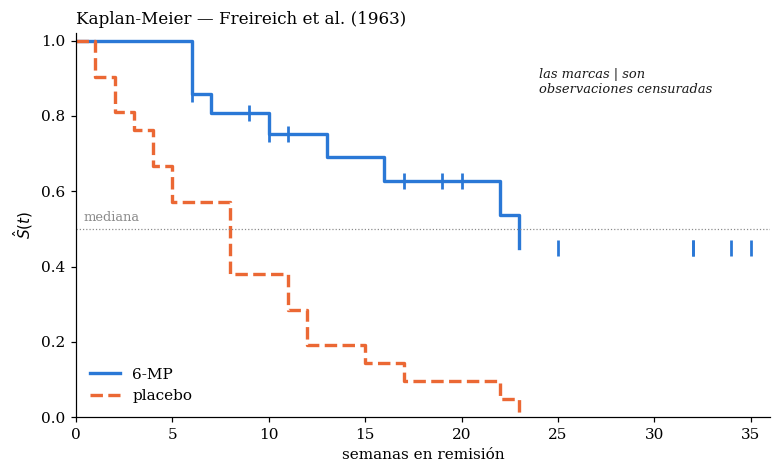

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))

for grupo, color, estilo in [("6-MP", AZUL, "-"), ("placebo", NARANJA, "--")]:
    tabla = tablas[grupo]
    t = np.concatenate([[0], tabla["t"].values])
    S = np.concatenate([[1], tabla["S"].values])
    ax.step(t, S, where="post", color=color, lw=2.2, ls=estilo, label=grupo)

    # marcas de censura sobre la curva
    sub = leucemia[(leucemia["grupo"] == grupo) & (leucemia["recaida"] == 0)]
    for tc in sub["semanas"]:
        previos = tabla[tabla["t"] <= tc]["S"]
        altura = previos.iloc[-1] if len(previos) else 1.0
        ax.plot([tc], [altura], marker="|", ms=11, mew=1.8, color=color)

ax.axhline(0.5, color=GRIS, lw=0.8, ls=":")
ax.text(0.4, 0.52, "mediana", color=GRIS, fontsize=8.5)
ax.set_xlabel("semanas en remisión")
ax.set_ylabel("$\\hat{S}(t)$")
ax.set_title("Kaplan-Meier — Freireich et al. (1963)", loc="left", fontsize=11)
ax.set_ylim(0, 1.02)
ax.set_xlim(0, 36)
ax.legend(frameon=False)
ax.text(24, 0.86, "las marcas | son\nobservaciones censuradas",
        fontsize=8.5, color=TINTA, style="italic")
plt.tight_layout()
plt.show()

## Prueba de rangos logarítmicos (*log-rank*)

Contrasta $H_0: S_1(t) = S_2(t)$ para todo $t$. En cada tiempo de falla se compara el
número de fallas observadas en un grupo contra las esperadas bajo la hipótesis nula
—una tabla $2\times2$ por tiempo, con distribución hipergeométrica—:

$$\chi^2 = \frac{(O_1 - E_1)^2}{V}$$

In [6]:
def log_rank(t1, e1, t2, e2):
    """Prueba de rangos logarítmicos para dos grupos."""
    t1, e1 = np.asarray(t1, float), np.asarray(e1, int)
    t2, e2 = np.asarray(t2, float), np.asarray(e2, int)

    momentos = np.unique(np.concatenate([t1[e1 == 1], t2[e2 == 1]]))
    O1 = E1 = V = 0.0
    for t in momentos:
        n1, n2 = (t1 >= t).sum(), (t2 >= t).sum()
        n = n1 + n2
        d1 = ((t1 == t) & (e1 == 1)).sum()
        d2 = ((t2 == t) & (e2 == 1)).sum()
        d = d1 + d2

        O1 += d1
        E1 += d * n1 / n
        if n > 1:
            V += d * (n1 / n) * (1 - n1 / n) * (n - d) / (n - 1)

    estadistico = (O1 - E1) ** 2 / V
    return estadistico, 1 - chi2.cdf(estadistico, 1), O1, E1


a = leucemia[leucemia["grupo"] == "6-MP"]
b = leucemia[leucemia["grupo"] == "placebo"]
est, pval, O1, E1 = log_rank(a["semanas"], a["recaida"], b["semanas"], b["recaida"])

print(f"Recaídas observadas en 6-MP : {O1:.0f}")
print(f"Recaídas esperadas bajo H0  : {E1:.2f}")
print(f"\nchi2(1) = {est:.3f}   p = {pval:.6f}")

Recaídas observadas en 6-MP : 9
Recaídas esperadas bajo H0  : 19.25

chi2(1) = 16.793   p = 0.000042


## Verificación

| | Nuestro cálculo | Publicado |
|---|---:|---:|
| Mediana 6-MP | 23 semanas | 23 semanas |
| Mediana placebo | 8 semanas | 8 semanas |
| Log-rank $\chi^2$ | 16.793 | 16.79 |

**La implementación reproduce el resultado publicado.** Ahora podemos usarla en un
problema cuya respuesta no conocemos, que es justamente para lo que sirve haberla
validado.

Obsérvese cuánta información aporta la censura correctamente tratada: se observan 9
recaídas en el grupo tratado donde la nula predice 19.25.

---
# Parte 2 — Una pregunta económica

## ¿Cuánto tarda un trabajador en afiliarse a un sindicato?

Usamos el panel de salarios que ya está en el repositorio
(`Clase_04_DatosPanel/wage_panel.csv`): 545 hombres jóvenes seguidos de 1980 a 1987,
provenientes de la NLSY y utilizados por **Vella y Verbeek (1998)**.

**Construcción del episodio.** Tomamos a los trabajadores que en 1980 **no** estaban
afiliados y medimos los años hasta su primera afiliación. Quien nunca se afilia durante el
periodo queda **censurado por la derecha en 1987**: sabemos que tardó más de siete años,
no cuánto.

Es exactamente la estructura de la parte 1, con datos económicos.

In [7]:
panel = pd.read_csv("../Clase_04_DatosPanel/wage_panel.csv").sort_values(["nr", "year"])

# En riesgo: quienes empiezan sin sindicato en 1980.
inicio = panel[panel["year"] == 1980].set_index("nr")
en_riesgo = inicio[inicio["union"] == 0].index

episodios = []
for nr, g in panel[panel["nr"].isin(en_riesgo)].groupby("nr"):
    g = g.sort_values("year")
    afiliado = np.where(g["union"].values == 1)[0]
    if len(afiliado):
        duracion, evento = g["year"].values[afiliado[0]] - 1980, 1
    else:
        duracion, evento = g["year"].values[-1] - 1980, 0     # censurado en 1987
    primera = g.iloc[0]
    episodios.append({
        "nr": nr, "duracion": duracion, "afiliacion": evento,
        "educ": primera["educ"], "black": primera["black"],
        "hisp": primera["hisp"], "married": primera["married"],
    })

duracion = pd.DataFrame(episodios)
duracion = duracion[duracion["duracion"] > 0].reset_index(drop=True)

print(f"Trabajadores en riesgo en 1980 : {len(duracion)}")
print(f"Se afilian durante el periodo  : {duracion['afiliacion'].sum()}")
print(f"Censurados en 1987             : {(duracion['afiliacion'] == 0).sum()}"
      f"  ({100 * (1 - duracion['afiliacion'].mean()):.1f} %)")
duracion.head()

Trabajadores en riesgo en 1980 : 408
Se afilian durante el periodo  : 143
Censurados en 1987             : 265  (65.0 %)


,nr,duracion,afiliacion,educ,black,hisp,married
0,13,1,1,14.0,0.0,0.0,0.0
1,17,7,0,13.0,0.0,0.0,0.0
2,18,7,0,12.0,0.0,0.0,1.0
3,120,7,0,10.0,0.0,0.0,0.0
4,126,7,0,13.0,0.0,0.0,0.0


## Por qué no basta con MCO sobre la duración

Antes de estimar bien, conviene ver qué pasa si se ignora la censura. Son las dos
estrategias ingenuas del capítulo 10:

In [8]:
solo_completos = duracion[duracion["afiliacion"] == 1]

print(f"a) Descartar censurados      : media = {solo_completos['duracion'].mean():.2f} años"
      f"   (N = {len(solo_completos)})")
print(f"b) Tratarlos como completos  : media = {duracion['duracion'].mean():.2f} años"
      f"   (N = {len(duracion)})")

km_union = kaplan_meier(duracion["duracion"], duracion["afiliacion"])
print(f"\nc) Kaplan-Meier              : S(7) = {km_union['S'].iloc[-1]:.3f}")
print(f"   -> el {100 * km_union['S'].iloc[-1]:.0f} % sigue sin afiliarse a los 7 años,")
print("      de modo que la mediana NI SIQUIERA está identificada con estos datos.")

a) Descartar censurados      : media = 2.86 años   (N = 143)
b) Tratarlos como completos  : media = 5.55 años   (N = 408)

c) Kaplan-Meier              : S(7) = 0.650
   -> el 65 % sigue sin afiliarse a los 7 años,
      de modo que la mediana NI SIQUIERA está identificada con estos datos.


Las dos estrategias ingenuas dan un número —2.5 y 5.5 años— y **ambas son engañosas**. La
primera sólo mira a quienes se afiliaron rápido; la segunda trata siete años de espera
como si fueran una afiliación.

Kaplan-Meier dice lo que de verdad se puede afirmar: al cabo de siete años, cerca del
64 % sigue sin afiliarse, así que la **mediana no está identificada**. Es una respuesta
menos cómoda y es la correcta.

> Ésta es la misma lógica del capítulo 8 —datos truncados y censurados— aplicada al
> tiempo. La censura no es un defecto de los datos que haya que limpiar: es información
> parcial que hay que usar como tal.

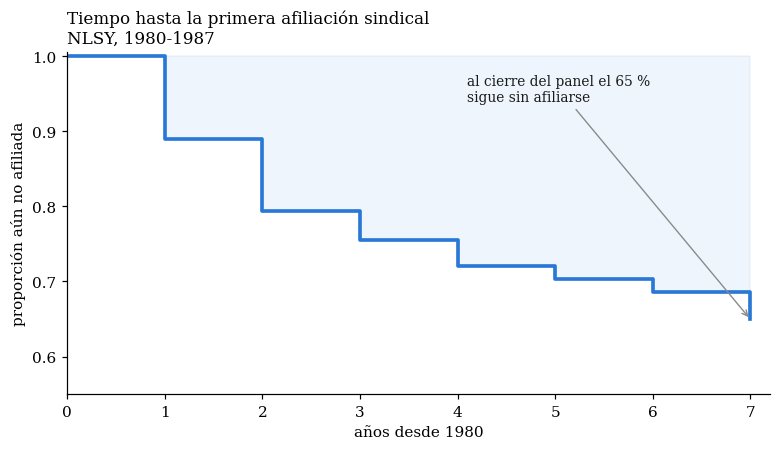

In [9]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))

t = np.concatenate([[0], km_union["t"].values])
S = np.concatenate([[1], km_union["S"].values])
ax.step(t, S, where="post", color=AZUL, lw=2.4)
ax.fill_between(t, S, 1, step="post", color=AZUL, alpha=0.07)

ax.set_xlabel("años desde 1980")
ax.set_ylabel("proporción aún no afiliada")
ax.set_title("Tiempo hasta la primera afiliación sindical\nNLSY, 1980-1987",
             loc="left", fontsize=11)
ax.set_ylim(0.55, 1.005)
ax.set_xlim(0, 7.2)
ax.annotate(f"al cierre del panel el {100 * S[-1]:.0f} %\nsigue sin afiliarse",
            xy=(7, S[-1]), xytext=(4.1, 0.94), fontsize=9, color=TINTA,
            arrowprops=dict(arrowstyle="->", color=GRIS, lw=0.9))
plt.tight_layout()
plt.show()

## Modelo de Weibull por máxima verosimilitud

Programamos la verosimilitud del capítulo 10 directamente. Con riesgo base de Weibull,
$\lambda(t) = \alpha t^{\alpha-1} e^{\mathbf{x}'\boldsymbol\beta}$, la contribución de
cada observación es

$$\ln L_i = d_i \left[\ln\alpha + (\alpha-1)\ln t_i + \mathbf{x}_i'\boldsymbol\beta\right]
- e^{\mathbf{x}_i'\boldsymbol\beta} t_i^{\alpha}$$

donde $d_i = 1$ si el episodio termina y $0$ si está censurado. **La censura no elimina la
observación: le quita el primer término y le deja el segundo**, que es la probabilidad de
haber sobrevivido hasta $t_i$.

El parámetro $\alpha$ gobierna la dependencia de la duración: $\alpha > 1$ riesgo
creciente, $\alpha < 1$ decreciente, $\alpha = 1$ constante (caso exponencial).

In [10]:
X = sm.add_constant(duracion[["educ", "black", "married"]]).values.astype(float)
t = duracion["duracion"].values.astype(float)
d = duracion["afiliacion"].values.astype(float)
NOMBRES = ["log_alpha", "const", "educ", "black", "married"]


def menos_log_verosimilitud(theta):
    alpha = np.exp(theta[0])            # se estima en logaritmos: alpha > 0
    xb = X @ theta[1:]
    riesgo = d * (np.log(alpha) + (alpha - 1) * np.log(t) + xb)
    acumulado = np.exp(xb) * t ** alpha
    return -np.sum(riesgo - acumulado)


ajuste = minimize(
    menos_log_verosimilitud,
    np.r_[0.0, -2.0, 0.0, 0.0, 0.0],
    method="Nelder-Mead",
    options=dict(maxiter=20000, maxfev=20000, xatol=1e-10, fatol=1e-10),
)


def hessiano(f, x, h=1e-5):
    """Hessiano por diferencias finitas centradas."""
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            xpp, xpm, xmp, xmm = (x.copy() for _ in range(4))
            xpp[i] += h; xpp[j] += h
            xpm[i] += h; xpm[j] -= h
            xmp[i] -= h; xmp[j] += h
            xmm[i] -= h; xmm[j] -= h
            H[i, j] = (f(xpp) - f(xpm) - f(xmp) + f(xmm)) / (4 * h * h)
    return H


V = np.linalg.inv(hessiano(menos_log_verosimilitud, ajuste.x))
ee = np.sqrt(np.diag(V))

weibull = pd.DataFrame(
    {"coef": ajuste.x, "ee": ee, "z": ajuste.x / ee}, index=NOMBRES
)
print(f"log-verosimilitud = {-ajuste.fun:.3f}\n")
weibull.round(4)

log-verosimilitud = -531.590



,coef,ee,z
log_alpha,0.0044,0.0779,0.0568
const,-1.7122,0.5139,-3.3316
educ,-0.0925,0.0418,-2.2118
black,0.6191,0.2380,2.6007
married,-0.2849,0.2432,-1.1712


### ¿Hay dependencia de la duración?

In [11]:
alpha = np.exp(ajuste.x[0])
ee_alpha = alpha * ee[0]            # método delta (apéndice A de las notas)
z = (alpha - 1) / ee_alpha

print(f"alpha = {alpha:.4f}   (ee {ee_alpha:.4f})")
print(f"H0: alpha = 1 (riesgo constante)")
print(f"   z = {z:.3f}   p = {1 - chi2.cdf(z ** 2, 1):.3f}")
print()
print("No se rechaza la hipótesis de riesgo constante: con estos datos el")
print("modelo de Weibull no mejora al exponencial. La tasa de afiliación no")
print("depende del tiempo que se lleve sin afiliarse.")

alpha = 1.0044   (ee 0.0783)
H0: alpha = 1 (riesgo constante)
   z = 0.057   p = 0.955

No se rechaza la hipótesis de riesgo constante: con estos datos el
modelo de Weibull no mejora al exponencial. La tasa de afiliación no
depende del tiempo que se lleve sin afiliarse.


> **Advertencia que conviene no saltarse.** No rechazar $\alpha = 1$ **no** demuestra que
> el riesgo individual sea constante. El capítulo 10 discute la **heterogeneidad no
> observada**: si conviven trabajadores con propensiones distintas, los de riesgo alto se
> afilian primero y el riesgo agregado observado **decrece** aunque el de cada individuo
> sea constante. El riesgo que estimamos aquí es el de la población superviviente, no el
> de un individuo. Con siete periodos y 65 % de censura no hay manera de separar ambas
> cosas.

## Modelo de riesgos proporcionales de Cox

Cox evita especificar el riesgo base $\lambda_0(t)$ y estima $\boldsymbol\beta$ por
**verosimilitud parcial** (la derivación está en el capítulo 10). A cambio de suponer
menos, no permite predecir duraciones absolutas: sólo compara riesgos entre individuos.

In [12]:
cox = sm.PHReg(
    duracion["duracion"],
    duracion[["educ", "black", "married"]],
    status=duracion["afiliacion"],
    ties="efron",
).fit()

print(cox.summary().tables[1])

           log HR  log HR SE        HR         t     P>|t|    [0.025    0.975]
educ    -0.090941   0.042152  0.913072 -2.157429  0.030972  0.840668  0.991711
black    0.606407   0.238118  1.833830  2.546664  0.010876  1.149933  2.924460
married -0.282303   0.243346  0.754045 -1.160092  0.246011  0.468016  1.214880


### Interpretación

Los coeficientes son **log-razones de riesgo**; su exponencial es la razón de riesgo.

- **`educ` = −0.091** → razón de riesgo 0.913. Cada año adicional de escolaridad reduce
  cerca de **9 %** la tasa instantánea de afiliación. Es consistente con que los
  trabajadores más escolarizados se emplean en ocupaciones menos sindicalizadas.
- **`black` = 0.606** → razón de riesgo 1.83: la tasa de afiliación es **83 % mayor**.
- **`married`** no es estadísticamente distinto de cero.

Nótese el paralelismo con el capítulo 7: la forma exponencial hace que $\beta$ se lea
como semielasticidad, igual que en el modelo de conteo de Poisson.

## Tiempo discreto: el modelo cloglog

Nuestras duraciones están medidas en **años enteros**, no en tiempo continuo. Cuando el
agrupamiento es grueso, el capítulo 10 recomienda el modelo de tiempo discreto con enlace
**complemento log-log**, que es el que resulta de agrupar un proceso de riesgos
proporcionales en intervalos.

Se estima expandiendo los datos a formato **persona-periodo**: un renglón por cada año en
que el trabajador estuvo en riesgo, con la variable dependiente igual a 1 sólo en el año
del evento.

In [13]:
filas = []
for _, fila in duracion.iterrows():
    for anio in range(1, int(fila["duracion"]) + 1):
        filas.append({
            "periodo": anio,
            "afilia": int(fila["afiliacion"] == 1 and anio == fila["duracion"]),
            "educ": fila["educ"], "black": fila["black"], "married": fila["married"],
        })

persona_periodo = pd.DataFrame(filas)
print(f"Renglones persona-periodo: {len(persona_periodo)}")
print(f"Eventos: {persona_periodo['afilia'].sum()}")
persona_periodo.head()

Renglones persona-periodo: 2264
Eventos: 143


,periodo,afilia,educ,black,married
0,1,1,14.0,0.0,0.0
1,1,0,13.0,0.0,0.0
2,2,0,13.0,0.0,0.0
3,3,0,13.0,0.0,0.0
4,4,0,13.0,0.0,0.0


In [14]:
cloglog = smf.glm(
    "afilia ~ educ + black + married + C(periodo)",
    data=persona_periodo,
    family=sm.families.Binomial(sm.families.links.CLogLog()),
).fit()

comparacion = pd.DataFrame({
    "Cox (verosimilitud parcial)": cox.params,
    "cloglog (tiempo discreto)": cloglog.params[["educ", "black", "married"]],
    "Weibull (MV completa)": ajuste.x[2:],
}, index=["educ", "black", "married"])
comparacion.round(4)

,Cox (verosimilitud parcial),cloglog (tiempo discreto),Weibull (MV completa)
educ,-0.0909,-0.0910,-0.0925
black,0.6064,0.6086,0.6191
married,-0.2823,-0.2827,-0.2849


## La verificación cruzada

Los tres estimadores parten de supuestos distintos —Cox no especifica el riesgo base,
cloglog lo deja libre por periodo, Weibull lo impone paramétrico— y **coinciden hasta la
segunda o tercera cifra decimal**.

Es el principio de las **dos implementaciones independientes** de la unidad 4: cuando dos
rutas de cálculo que no comparten código llegan al mismo número, es muy improbable que
ambas estén mal de la misma manera. Y explica *por qué* coinciden: el modelo de tiempo
discreto con enlace cloglog es el que se obtiene al agrupar un proceso de riesgos
proporcionales, de modo que la coincidencia es una predicción teórica que aquí se
comprueba.

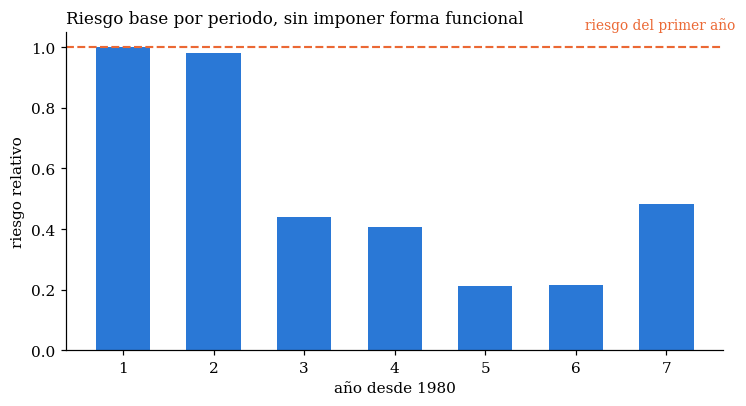

El riesgo base no muestra una tendencia clara, lo que concuerda con
el alpha de Weibull cercano a 1 (1.004).


In [15]:
riesgo_base = np.exp(
    cloglog.params[[c for c in cloglog.params.index if c.startswith("C(periodo)")]]
)
riesgo_base = pd.concat([pd.Series({"periodo 1 (base)": 1.0}), riesgo_base])

fig, ax = plt.subplots(figsize=(7.0, 3.8))
ax.bar(range(1, len(riesgo_base) + 1), riesgo_base.values, color=AZUL, width=0.6)
ax.axhline(1.0, color=NARANJA, lw=1.4, ls="--")
ax.text(6.1, 1.06, "riesgo del primer año", color=NARANJA, fontsize=9)
ax.set_xlabel("año desde 1980")
ax.set_ylabel("riesgo relativo")
ax.set_title("Riesgo base por periodo, sin imponer forma funcional",
             loc="left", fontsize=11)
plt.tight_layout()
plt.show()

print("El riesgo base no muestra una tendencia clara, lo que concuerda con")
print(f"el alpha de Weibull cercano a 1 ({alpha:.3f}).")

---
## Ejercicios

Los ejercicios 1 a 8 del **capítulo 10 de las Notas de Clase** acompañan a este cuaderno.
Estos son los que se resuelven con código:

1. **Kaplan-Meier a mano.** Con los datos del ejercicio 6 del capítulo 10 —duraciones
   3, 5, 5\*, 7, 9\*, 9, 12, 14\*, 14, 18, donde \* marca censura— construye la tabla de
   vida y verifica tu resultado con la función `kaplan_meier` de este cuaderno.
2. **El efecto de ignorar la censura.** Repite el análisis de la parte 2 descartando a los
   censurados. ¿En qué dirección se sesga cada coeficiente de Cox? Explica el mecanismo,
   no sólo el signo.
3. **Exponencial contra Weibull.** Estima el modelo exponencial (imponiendo $\alpha = 1$)
   y contrástalo con el de Weibull mediante una prueba de razón de verosimilitudes.
   Compara el resultado con la prueba de Wald sobre $\alpha$ que hicimos arriba: el
   capítulo 6 predice que deben coincidir asintóticamente. ¿Lo hacen?
4. **Riesgos proporcionales.** El supuesto central de Cox es que las razones de riesgo no
   dependen del tiempo. Contrástalo interactuando `black` con el periodo en el modelo
   cloglog. ¿Se sostiene?
5. **Heterogeneidad no observada.** Simula dos tipos de trabajadores con riesgos
   constantes distintos ($\lambda_A = 0.30$, $\lambda_B = 0.05$) y estima un Weibull sobre
   la muestra combinada. ¿Qué $\alpha$ recuperas? Relaciónalo con la advertencia de este
   cuaderno y con la figura de dependencia negativa espuria del capítulo 10.
6. **Otra pregunta con los mismos datos.** Construye la duración del *primer empleo
   sindicalizado*: entre quienes sí se afilian, cuántos años permanecen afiliados. ¿Cómo
   cambia la estructura de censura? ¿Y el problema de muestreo de acervo frente al de
   flujo que discute el capítulo 10?

---

## Datos y referencias

- **Freireich, E. J. *et al.* (1963).** «The effect of 6-mercaptopurine on the duration of
  steroid-induced remissions in acute leukemia», *Blood* 21(6): 699-716. Reproducido en
  Kleinbaum y Klein, *Survival Analysis: A Self-Learning Text*.
- **Vella, F. y M. Verbeek (1998).** «Whose wages do unions raise? A dynamic model of
  unionism and wage rate determination for young men», *Journal of Applied Econometrics*
  13(2): 163-183. Fuente del panel `wage_panel.csv`.
- **Cox, D. R. (1972).** «Regression models and life-tables», *JRSS B* 34(2): 187-220.
- **Kaplan, E. L. y P. Meier (1958).** «Nonparametric estimation from incomplete
  observations», *JASA* 53(282): 457-481.
- **Kiefer, N. M. (1988).** «Economic duration data and hazard functions», *Journal of
  Economic Literature* 26(2): 646-679. La referencia estándar para economistas.

---
Parte del curso de **Econometría I**, Facultad de Ciencias, UNAM.
Teoría en el **capítulo 10** de las Notas de Clase.
Ver el [README principal](../README.md) para la correspondencia entre temario, notas y código.